<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/%20Chapter-8-Generalized_Solutions/Untitled183.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Finding a Linear Continuous Functional on $L^2(0, 1)$:**

We consider the domain
$
\Omega=(0,1)
$
and the Hilbert space
$
L^2(0,1)$.
For parameters $\alpha,\beta>0$, we introduce the normalized functions
$$
u_{\alpha,\beta}(x)
=
C_{\alpha,\beta}\,
x^{\frac{\alpha-1}{2}}
(1-x)^{\frac{\beta-1}{2}},
$$
where the normalization constant is chosen as
$$
C_{\alpha,\beta}
=
\left(
\frac{\Gamma(\alpha+\beta)}
{\Gamma(\alpha)\Gamma(\beta)}
\right)^{1/2}.
$$
These functions are normalized in \(L^2(0,1)\), namely
$$
\|u_{\alpha,\beta}\|_{L^2}=1.
$$



Suppose that we are given measurements
$$
F_{\alpha,\beta}
=
F(u_{\alpha,\beta}),
$$
where $F$ is an unknown continuous linear functional on $L^2(0,1)$. Our goal is to reconstruct the functional $F$ from these observations.


Epoch     0 | Loss = 2.509059e-01
Epoch   500 | Loss = 4.428460e-05
Epoch  1000 | Loss = 3.070616e-06
Epoch  1500 | Loss = 3.026743e-06
Epoch  2000 | Loss = 2.972029e-06
Epoch  2500 | Loss = 2.901941e-06
Epoch  3000 | Loss = 2.814783e-06
Epoch  3500 | Loss = 2.708979e-06
Epoch  4000 | Loss = 2.583411e-06
Epoch  4500 | Loss = 2.437659e-06
Epoch  5000 | Loss = 2.272642e-06
Epoch  5500 | Loss = 2.090590e-06
Epoch  6000 | Loss = 1.895324e-06
Epoch  6500 | Loss = 1.691931e-06
Epoch  7000 | Loss = 1.486415e-06
Epoch  7500 | Loss = 1.284880e-06


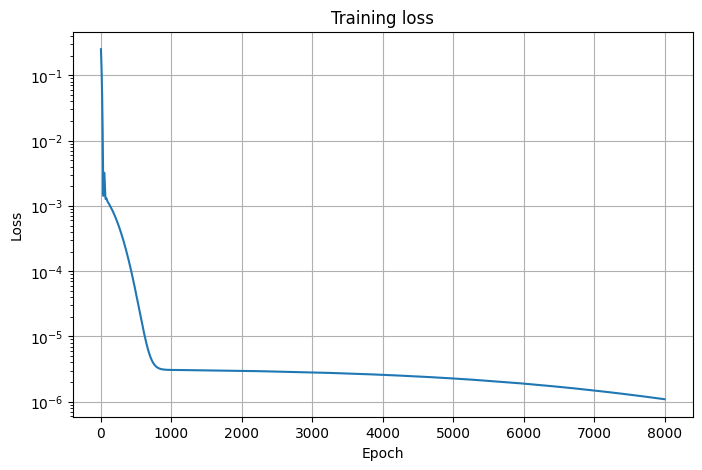

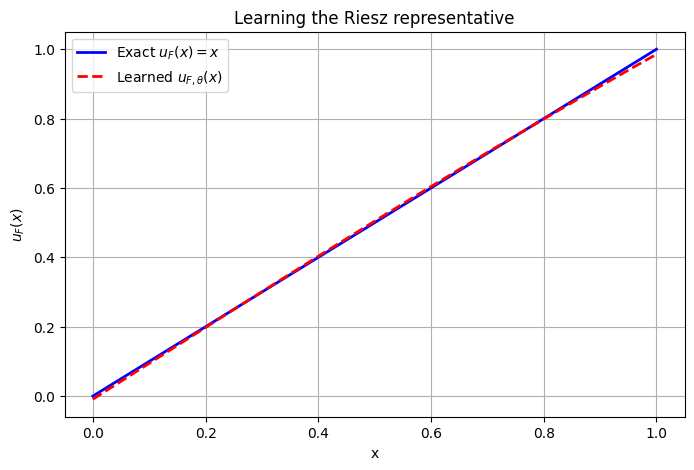

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.special import gamma

# =========================
# Parameters
# =========================
N_quad = 1000
EPOCHS = 8000
lr = 2e-4

# Quadrature grid on (0,1)
x_np = np.linspace(1e-5, 1 - 1e-5, N_quad).reshape(-1, 1)
x_tf = tf.constant(x_np, dtype=tf.float32)
dx = 1.0 / N_quad

# =========================
# Normalized functions u_{alpha,beta}
# =========================
def C_alpha_beta(alpha, beta):
    return np.sqrt(gamma(alpha + beta) / (gamma(alpha) * gamma(beta)))

def u_alpha_beta(alpha, beta, x):
    C = C_alpha_beta(alpha, beta)
    return C * x**((alpha - 1)/2) * (1 - x)**((beta - 1)/2)

# =========================
# Exact synthetic functional data
# u_F(x) = x
# F_{alpha,beta} = int_0^1 u_{alpha,beta}(x) x dx
# =========================
def F_exact(alpha, beta):
    C = C_alpha_beta(alpha, beta)
    return C * gamma((alpha + 3)/2) * gamma((beta + 1)/2) / gamma((alpha + beta)/2 + 2)

# Build dataset
alphas = np.arange(1, 8)
betas = np.arange(1, 8)

u_data = []
F_data = []

for alpha in alphas:
    for beta in betas:
        u_vals = u_alpha_beta(alpha, beta, x_np)
        F_val = F_exact(alpha, beta)

        u_data.append(u_vals.flatten())
        F_data.append(F_val)

u_data = tf.constant(np.array(u_data), dtype=tf.float32)   # shape (49, N_quad)
F_data = tf.constant(np.array(F_data).reshape(-1, 1), dtype=tf.float32)

# =========================
# Neural network for u_F(x)
# =========================
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])

model = build_model()
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

# =========================
# Loss function
# =========================
def compute_loss():
    uF_theta = model(x_tf)                 # shape (N_quad, 1)
    uF_theta_flat = tf.reshape(uF_theta, (1, -1))  # shape (1, N_quad)

    # Approximate int_0^1 u_{alpha,beta}(x) u_F_theta(x) dx
    F_pred = dx * tf.reduce_sum(u_data * uF_theta_flat, axis=1, keepdims=True)

    loss = tf.reduce_mean(tf.square(F_pred - F_data))
    return loss

# =========================
# Training loop
# =========================
loss_history = []

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        loss = compute_loss()

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_value = loss.numpy().item()
    loss_history.append(loss_value)

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss = {loss_value:.6e}")

# =========================
# Plot loss
# =========================
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid()
plt.show()

# =========================
# Plot learned Riesz representative
# =========================
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)
x_plot_tf = tf.constant(x_plot, dtype=tf.float32)

uF_learned = model(x_plot_tf).numpy().flatten()
uF_exact = x_plot.flatten()

plt.figure(figsize=(8,5))
plt.plot(x_plot, uF_exact, "b-", linewidth=2, label=r"Exact $u_F(x)=x$")
plt.plot(x_plot, uF_learned, "r--", linewidth=2, label=r"Learned $u_{F,\theta}(x)$")
plt.xlabel("x")
plt.ylabel(r"$u_F(x)$")
plt.title("Learning the Riesz representative")
plt.legend()
plt.grid()
plt.show()